# Predicting if a person would buy life insurnace based on his age and bmi using linear regression

## Introduction
- The insurance industry depends heavily on accurate risk assessment to determine the medical charges billed to customers. Factors such as age, BMI, smoking habits, number of dependents, sex, and geographic region can all play a significant role in influencing how much a person is charged for health insurance. With the growing availability of structured customer data, machine learning offers a powerful way to model and predict these charges based on individual characteristics.
- This project applies Linear Regression one of the foundational supervised learning algorithms to explore and quantify the relationships between patient attributes and their medical insurance costs. The dataset contains 1,338 records with 7 features, including both numerical and categorical variables, making it an ideal case study for regression modeling, feature encoding, and predictive analytics.
## Problem Statement
- Given a set of personal and demographic attributes of an individual — including age, sex, BMI (Body Mass Index), number of children, smoking status, and residential region the goal is to predict the medical insurance charges billed to that person.
- Specifically, this project aims to:

    - Understand the key factors that drive variation in insurance charges through exploratory data analysis.
    - Build a Linear Regression model trained on encoded features to predict the continuous target variable charges.
    - Evaluate model performance using metrics such as MAE, RMSE, and R² score on both training and test sets.
    - Visualize the relationships between key predictors (BMI, age, smoking status) and the insurance charges.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.preprocessing import LabelEncoder    

- Importing Libraries: Data manipulation, visualization, and ML modeling

In [15]:
df=pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


- Load Dataset

In [16]:
df.shape

(1338, 7)

In [17]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [18]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [19]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

- Displays dataset shape, types, statistics, and missing values


In [20]:
data=df.copy()

- Create a copy for processing

In [21]:
le_sex= LabelEncoder()
le_smoker= LabelEncoder()
le_region= LabelEncoder()
data['sex']=le_sex.fit_transform(data['sex'])
data['smoker']=le_smoker.fit_transform(data['smoker'])
data['region']=le_region.fit_transform(data['region'])

- Encode categorical variables

In [22]:
print(f"\nSmoking Status Mapping: {dict(zip(le_smoker.classes_, le_smoker.transform(le_smoker.classes_)))}")
print(f"Sex Mapping: {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}")


Smoking Status Mapping: {'no': np.int64(0), 'yes': np.int64(1)}
Sex Mapping: {'female': np.int64(0), 'male': np.int64(1)}


In [23]:
X=data.drop('charges',axis=1)
Y=data['charges']

- Prepare features and target

In [24]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 1070
Test set size: 268


- Splits data into 80% training and 20% testing

In [25]:
model= LinearRegression()
model.fit(X_train,Y_train)
print("\nLinear Regression Model trained successfully!")


Linear Regression Model trained successfully!


- Creates and trains the Linear Regression model

In [26]:
# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
print(y_pred_train)
print(f"\n{y_pred_test}")

[ 7155.72095161  8301.24368501  9225.27847635 ... 11397.1643032
 37231.82236887 11398.71025918]

[ 8924.40724442  7116.29501758 36909.01352144  9507.87469118
 27013.3500079  10790.77956153   226.29844571 16942.71599941
  1056.63079407 11267.91997309 28048.59793155  9424.36324087
  5326.32232088 38460.06017922 40303.40597026 37147.01010262
 15287.91876684 35965.05485917  9179.1753067  31510.8319849
  3797.79068365 10070.82803304  2312.57551348  7074.41348194
 11352.37224357 12907.77079523 14448.84678727  6205.65997921
  9917.00839638  2239.50032819  9060.55469043 13120.56214535
  4617.70702822  3467.91218926  4402.74821855 12967.91608907
  1927.44498944  8757.9180081  33324.35180597 32638.47697026
  3852.41756615  4370.39670883 14080.76023234 11478.63402576
  8829.26135924 12046.15119133  5322.80515731  3100.71182484
 35546.60547574  9201.61196817 15894.23763341  2406.04003607
 12397.52052544  1433.90617387 13448.14094304 12519.54174599
  4295.28664609 32202.67982224 13263.171278   1284

# Model Evaluation

In [27]:
# Training metrics
train_mae=mean_absolute_error(Y_train,y_pred_train)
train_rmse=np.sqrt(mean_squared_error(Y_train,y_pred_train))
train_r2=model.score(X_train,Y_train)
print("\nTraining Set Metrics:")
print(f"  MAE (Mean Absolute Error):  ${train_mae:,.2f}")
print(f"  RMSE (Root Mean Squared Error): ${train_rmse:,.2f}")
print(f"  R² Score: {train_r2:.4f}")


Training Set Metrics:
  MAE (Mean Absolute Error):  $4,208.76
  RMSE (Root Mean Squared Error): $6,105.79
  R² Score: 0.7417


In [28]:
# Test metrics
test_mae= mean_absolute_error(Y_test,y_pred_test)
test_rmse=np.sqrt(mean_squared_error(Y_test,y_pred_test))
test_r2=model.score(X_test,Y_test)
print("\nTest Set Metrics:")
print(f"  MAE (Mean Absolute Error):  ${test_mae:,.2f}")
print(f"  RMSE (Root Mean Squared Error): ${test_rmse:,.2f}")
print(f"  R² Score: {test_r2:.4f}")


Test Set Metrics:
  MAE (Mean Absolute Error):  $4,186.51
  RMSE (Root Mean Squared Error): $5,799.59
  R² Score: 0.7833


# Create visualizations

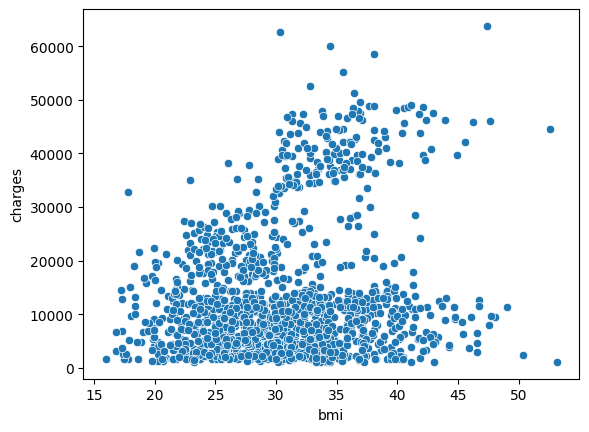

In [29]:
# 1. BMI vs Charges
sns.scatterplot(data=df,x=df['bmi'],y=df['charges'])
plt.show()

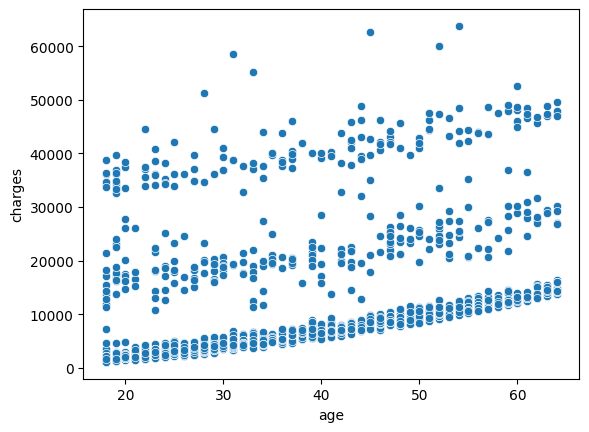

In [30]:
# 2. Age vs Charges
sns.scatterplot(data=df,x=df['age'],y=df['charges'])
plt.show()

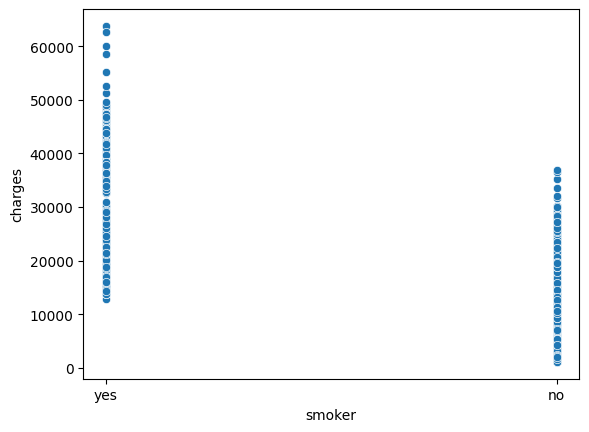

In [31]:
# 1. Smoking status vs Charges
sns.scatterplot(data=df,x=df['smoker'],y=df['charges'])
plt.show()